# Wave-following diagnostics, single ensemble member
Generates a time series of a user specified box average following the wave, from data using the QTRACK tool (Lawton, et al. 2022)

In [1]:
from __future__ import print_function
import pkg_resources
import os
#from os import listdir
#from os.path import isfile, join
import glob
import metpy
import subprocess
import wrf
import numpy as np
from netCDF4 import Dataset

import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import matplotlib.cbook as cbook
import cartopy.crs as crs
import cartopy.feature as cfeature
from metpy.units import units

from cartopy.feature import NaturalEarthFeature

from wrf import (to_np, interplevel, geo_bounds, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, destagger)
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches


from metpy.plots import ctables

import metpy.calc as mpcalc
import xarray as xr
import pandas as pd

/glade/derecho/scratch/athornton/tmp/ipykernel_74798/2675992302.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## The following are lists to select each ensemble set and respective initialization time
variation = ['fluxon', 'rst_on24', 'rst_on36', 'rst_on48', '', 'fluxoff', '', '', '']
init_times = ['0300','0303','0306',
             '0309','0312','0315',
             '0318','0321','0400']

In [3]:
#########################################
### MAKE SELECTIONS HERE
#set = 'Fluxes on'          # try: '24 hours without fluxes'
set_name = variation[1]     # try: variation[1]
wave = 'second'             # 'second' == Paulette or 'main' == Rene
title = '24 hrs decoupled'  # What will be displayed on main plot
ens = init_times[0]

## 
if wave == 'main':
    name = 'Rene'
else:
    name = 'Paulette'

In [4]:
plotsdir = '/glade/u/home/athornton/qtrack/'

In [5]:
save_name = set_name +"_"+ ens
save_name

'rst_on24_0300'

## First get the track of the wave

In [10]:
df = xr.open_dataset('/glade/u/home/athornton/qtrack/'+wave+'_wave/'+wave+'_wave_track_'+save_name+'.nc')

## Now get the corresponding WRF run
We will select only the data from the wrf run that corresponds to this wave track, in a 1x1 degree box following the wave. 

In [11]:
# Set directory where wrfout files reside, and list the files for processing.  Set up for a directory with only wrfout files.
os.chdir("/glade/campaign/univ/uncs0067/flux_experiments/cent_atl_case/init"+ens+"z/"+set_name+"/")
plotsdir = "/glade/u/home/athornton/wrf_visualization/plots/restart/init"+ens+"z/"+set_name+"/"


In [12]:
datafiles = sorted(glob.glob("./wrfout*"))
numfiles=len(datafiles)
print(numfiles)
print(datafiles[0])

53
./wrfout_d01_2020-09-03_00:00:00


In [13]:
# From Anantha...
# Simple linear interpolation between each latitude point
def get_lats():
    new_lats = []
    wave_track_lats = df.lat[-len(times_list):]
    for i in range(0,len(wave_track_lats)):
        if wave_track_lats[i] == wave_track_lats[-1]:
            new_lats.append(wave_track_lats[i].values)
        else:
            next_value = 0.5*(wave_track_lats[i] + wave_track_lats[i+1])
            new_lats.append(wave_track_lats[i].values)
            new_lats.append(next_value.values)
    return new_lats

In [14]:
# From Anantha...
# Simple linear interpolation between each longitude point
def get_lons():
    new_lons = []
    wave_track_lons = df.lon[-len(times_list):] 
    for i in range(0,len(wave_track_lons)):
        if wave_track_lons[i] == wave_track_lons[-1]:
            new_lons.append(wave_track_lons[i].values)
        else:
            next_value = 0.5*(wave_track_lons[i] + wave_track_lons[i+1])
            new_lons.append(wave_track_lons[i].values)
            new_lons.append(next_value.values)
    return new_lons

In [15]:
init_time ='2020-09-'+ens[:2]+' '+ens[2:]+':00'
end_time  ='2020-09-09 12:00'

In [16]:
times_list = pd.date_range(start=init_time, end=end_time, freq='6h')

In [17]:
wave_track_lats = get_lats()
wave_track_lons = get_lons()

In [18]:
wrf_out_data = xr.open_dataset(datafiles[0])  
p =wrf_out_data['P']

In [19]:
def mass_weighted_vert_integral(height, data):
    # data is expected to be on pressure levels
    levels = p.bottom_top
    deltaP = (levels - levels.shift(bottom_top=1))
    vert_int_data = ((data.shift(bottom_top=1)+data)*.5*deltaP).sum(dim='bottom_top') / metpy.constants.earth_gravity    
    return  vert_int_data

In [20]:
# Set up loop to run same plots for multiple different times (assume here that we have 1 time per wrfout file)
winds_list = []
moist_list = []
vo850_list = []
vo700_list = []
vo600_list = []

WRF_OUT_DATA = [] 
date = []

for i in range(0,len(datafiles)):
    # for j in range(0,1):
    ncfile = Dataset(datafiles[i])
    Time=wrf.extract_times(ncfile, timeidx=0, method='cat', squeeze=True, cache=None, meta=False, do_xtime=False)
    timestr=(str(Time))
    # Set up one time string for plot titles, another for file names
    titletime=(timestr[0:10]+' '+timestr[11:16])
    filetime=(timestr[0:10]+'_'+timestr[11:16])
    print('WRF valid time: ',filetime)

    wrf_out_data = xr.open_dataset(datafiles[i])  
    WRF_OUT_DATA.append(wrf_out_data)
    time = wrf_out_data['XTIME'][0].values
    time_changed = time.astype(np.datetime64)
    ts = pd.to_datetime(str(time_changed))
    d = ts.strftime('%Y-%m-%d %H:%M')
    date.append(d)
    
    # Get all the variables we need
    qwv = wrf_out_data["QVAPOR"]
    ua = wrf_out_data["U"]
    va = wrf_out_data["V"]

    lats, lons = latlon_coords(wrf_out_data['P'])
    lats_np = to_np(lats)
    lons_np = to_np(lons)
    lats_np = lats_np[0,:,0]
    lons_np = lons_np[0,0,:]
    
    # Unstagger the winds to match the pressure grid
    ua = destagger(ua, stagger_dim=3)             # Unstagger U in the x-direction
    va = destagger(va, stagger_dim=2)             # Unstagger V in the x-direction

    # Grid spacing for vorticity calculation
    dx = ncfile.DX * units("m")
    dy = ncfile.DY * units("m")
    
    u_winds = xr.DataArray(ua)[0]
    v_winds = xr.DataArray(va)[0]
    qwv =  xr.DataArray(qwv)[0]
    
    u_sfc = u_winds.sel(dim_1=1)*units('m/s')     # select surface winds
    v_sfc = v_winds.sel(dim_1=1)*units('m/s')     # select surface winds
    wind_sfc = mpcalc.wind_speed(u_sfc, v_sfc)

    u_600 = u_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
    v_600 = v_winds.sel(dim_1=19)*units('m/s')    # select 630 hPa winds
    vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
    vo600=to_np(vo600)

    u_700 = u_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds
    v_700 = v_winds.sel(dim_1=17)*units('m/s')    # select 700 hPa winds 
    vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
    vo700=to_np(vo700)
    
    u_850 = u_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
    v_850 = v_winds.sel(dim_1=12)*units('m/s')    # select 850 hPa winds
    vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)
    vo850=to_np(vo850)
    
    lat_lon = [wave_track_lats[i],wave_track_lons[i]]                 # Lat, Lon cooridante of center of square we are interested in
    
    x_ycenter = wrf.ll_to_xy(ncfile, lat_lon[0], lat_lon[1])

    # specify how big you want the wave-following box to be
    delta = 50                                      # in grid points 

    winds = wind_sfc[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)]

    # wave tracks have nans at the beginning so return nan if it's the beginning of the track
    if not winds.any():
        max_wind = np.nan
    else:
        max_wind = np.max(winds.values)

    columnq = mass_weighted_vert_integral(p, qwv)
    avg_qwv = columnq[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
    avg_850 = vo850[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
    avg_700 = vo700[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
    avg_600 = vo600[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()

    winds_list.append(max_wind)
    moist_list.append(avg_qwv)
    vo850_list.append(avg_850)
    vo700_list.append(avg_700)
    vo600_list.append(avg_600)
    

WRF valid time:  2020-09-03_00:00


/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:58: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:63: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:68: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-03_03:00


/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:58: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:63: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:68: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-03_06:00


...

/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:58: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:63: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:68: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-09_09:00


/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:58: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:63: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:68: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


WRF valid time:  2020-09-09_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:58: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo600=metpy.calc.vorticity(u_600, v_600, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:63: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo700=metpy.calc.vorticity(u_700, v_700, dx=dx, dy=dy)
/glade/derecho/scratch/athornton/tmp/ipykernel_74798/1699682255.py:68: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo850=metpy.calc.vorticity(u_850, v_850, dx=dx, dy=dy)


## Now get rain data

In [21]:
# open all wrfout files for this ensemble member
data = xr.open_mfdataset(datafiles, concat_dim='Time', combine='nested', engine='netcdf4')
rain = data.RAINC
time = data.XTIME.compute()
rain_list = [np.zeros_like(rain[0])]  # Start with a zero array for the first time step

for i in range(1, len(rain)):
    rain_hour = rain[i] - rain[i-1] # subtract computed accumulated rain note from previous timestep
    rain_hour = np.maximum(rain_hour, 0)  # Set negative values to 0
    rain_list.append(rain_hour)

rain = xr.DataArray(rain_list)

In [22]:
# Apply wavetrack to this rain data and only choose points within our wave-following box
rain_box_list = []
for i in range(0,len(datafiles)):
    lat_lon = [wave_track_lats[i],wave_track_lons[i]]      # Lat, Lon cooridante of center of square we are interested in
    x_ycenter = wrf.ll_to_xy(ncfile, lat_lon[0], lat_lon[1])

    # specify how big you want the wave-following box to be
    delta = 50                                # in grid points 
    rain_inc = rain[i]
    rain_box = rain_inc[int(x_ycenter[1]-delta):int(x_ycenter[1]+delta),int(x_ycenter[0]-delta):int(x_ycenter[0]+delta)].mean()
    rain_box_list.append(rain_box)

In [23]:
times = pd.date_range(init_time, end_time, freq='3h')

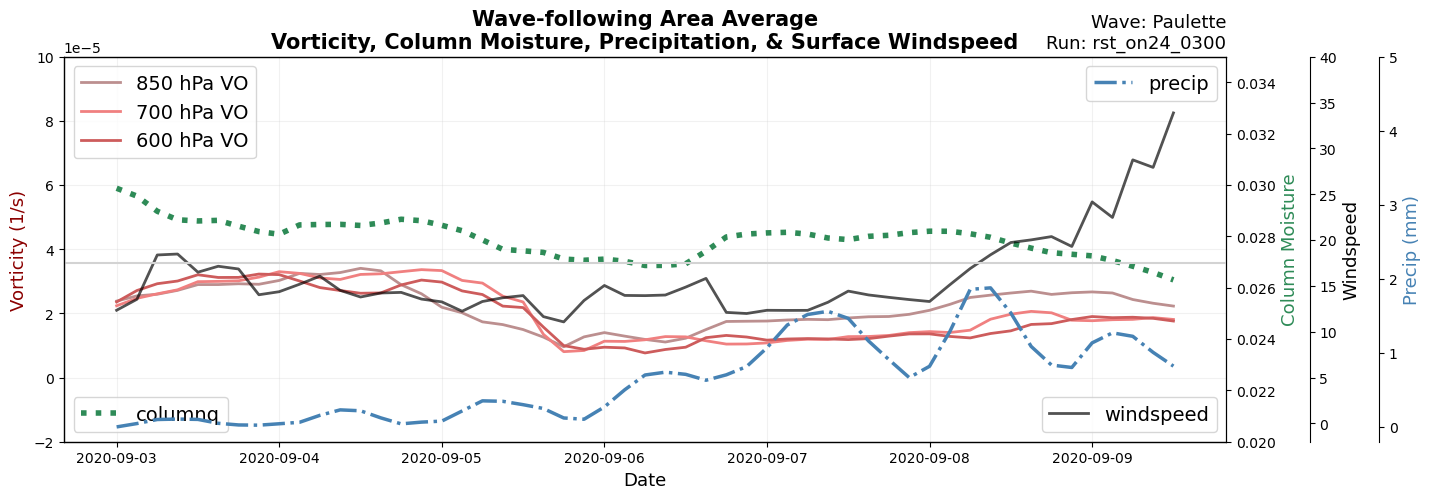

In [40]:
plt.rcParams['savefig.dpi'] = 255
fig, ax = plt.subplots(figsize=(15,5))

ax.set_title('Wave-following Area Average\nVorticity, Column Moisture, Precipitation, & Surface Windspeed', size=15, weight='bold')
#ax.set_title(wave, loc='right')
plt.title('Wave: '+name+'\nRun: '+save_name, loc='right', fontsize=13)
ax.set_ylabel('Vorticity (1/s)', color='darkred',size =13)
ax.set_xlabel('Date', size=13)
ax.plot(times, vo850_list, color='rosybrown', label='850 hPa VO', linewidth=2.)
ax.plot(times, vo700_list, color='lightcoral', label='700 hPa VO', linewidth=2.)
ax.plot(times, vo600_list, color='indianred', label='600 hPa VO', linewidth=2.)
ax.set_ylim(-0.00002,0.00010)
ax.legend(loc='upper left', fontsize=14)

ax2=ax.twinx()
ax2.plot(times, moist_list, color='seagreen', label='columnq', linestyle=':', linewidth=4.)
ax2.set_ylim(0.02,0.035)
ax2.legend(loc='lower left', fontsize=14)
ax2.set_ylabel('Column Moisture', size=13, color='seagreen')

ax3=ax.twinx()
ax3.plot(times, winds_list, color='black', label='windspeed', linewidth=2., alpha=0.68)
ax3.set_ylim(-2,40)
ax3.set_ylabel('Windspeed', size=13, color='black')
ax3.spines['right'].set_position(('outward', 60))
ax3.legend(loc='lower right', fontsize=14)

ax4=ax.twinx()
ax4.plot(times, rain_box_list, color='steelblue', label='precip', linestyle='-.', linewidth=2.5)
ax4.set_ylim(-0.2,5)
ax4.spines['right'].set_position(('outward', 110))
ax4.set_ylabel('Precip (mm)', size=13, color='steelblue')
ax4.legend(loc='upper right', fontsize=14)
ax.grid(color='lightgray',alpha=0.3)

ax3.axhline(y=17.5, color='lightgray')

#plt.savefig(plotsdir+'wave_following_'+wave+'.png')



In [40]:
winds_list

[5.751339,
 8.407684,
 10.043279,
 12.602641,
 14.393678,
 11.452859,
 11.761311,
 11.042343,
 13.363969,
 13.727524,
 11.300961,
 10.554902,
 8.973655,
 9.886645,
 18.685883,
 20.648155,
 20.687239,
 18.220158,
 12.442092,
 12.904306,
 13.215425,
 10.4391775,
 17.135912,
 22.392485,
 18.680363,
 13.842298,
 21.719986,
 15.9473095,
 15.098827,
 9.878279,
 11.707411,
 10.371854,
 13.954518,
 16.218313,
 22.777952,
 21.264118,
 18.956388,
 18.264969,
 13.674935,
 11.856462,
 12.332592,
 12.00319,
 12.045222,
 11.69835,
 11.812512,
 11.459277,
 11.4312525,
 11.722077,
 11.416729,
 10.977051,
 10.877709,
 11.600134,
 11.301868]